# Chapter D. Spatial Statistics

## Learning Objectives

After completing this chapter, you should be able to:
1. Distinguish CSR（完全空间随机）from conditional random labeling.
2. Simulate homogeneous Poisson event patterns and aggregate occupancy in disks.
3. Derive positive covariance caused by overlapping spatial supports.
4. Show why shared events invalidate unrestricted transaction-label permutations.
5. Contrast equal disks with uneven event intensity and point-process references.

**Connection to STARM:** The examples mirror the binary outcome, fixed antecedent indicators, lagged transactions, and overlapping spatial supports in the STARM manuscript. They are teaching examples, not reproductions of manuscript results.

> **Teaching philosophy:** start with the general statistical problem, build mathematical intuition, and use STARM as one illustrative case study. The new sections precede the original computational labs.

## Why Study This? — Motivation, Scope, and Real-World Problems

Ordinary statistics often assumes independent observations. Geographical data violate this because nearby locations share environments, interactions, and even the same events. **Spatial statistics (空间统计学)** studies point locations, geographic surfaces, spatial dependence, and uncertainty while respecting where observations occur. Applications include epidemiology, ecology, crime analysis, geosciences, and public-health surveillance.

**Questions it answers:** Is an observed cluster unusual? How should we model event intensity? What does proximity do to variance and inference? Does the spatial support or aggregation unit change a result?

---

## Conceptual Roadmap

**Scientific problem → statistical representation → assumptions → mathematics → computational experiment → diagnostics → interpretation.**

The chapters are standalone: STARM is a later application, not the reason these mathematical ideas exist.

## Foundations and Mathematical Derivations

### Three representations, three statistical questions
1. **Point patterns (点模式)** model the event locations $\{s_j\}$; e.g. disease cases or ignitions.
2. **Geostatistical fields (地统计场)** model a continuous $Z(s)$; e.g. temperature, pollution. Spatial covariance is $C(h)=\mathrm{Cov}[Z(s),Z(s+h)]$ for a stationary field.
3. **Areal/lattice data (区域数据)** summarize attributes in polygons; spatial neighbors can be encoded through $W=[w_{ij}]$.

### CSR, intensity, and Ripley's K
Under homogeneous **complete spatial randomness (CSR, 完全空间随机性)**, events follow a Poisson process with intensity $\lambda$: for region $A$, $N(A)\sim\mathrm{Poisson}(\lambda|A|)$, and counts on *disjoint* regions are independent. The void probability is $P[N(A)=0]=e^{-\lambda|A|}$. Under CSR (ignoring edge issues), the theoretical $K$-function equals $K(r)=\pi r^2$. Observed clustering can also reflect **inhomogeneous intensity**, not genuine interaction.

### Why overlapping supports induce covariance
Let $Y_A=1\{N(A)>0\}$ and $Y_B=1\{N(B)>0\}$ under homogeneous Poisson CSR. Since

$$P(Y_A=0,Y_B=0)=e^{-\lambda|A\cup B|},$$

and $P(Y_A=0)=e^{-\lambda|A|}$, $P(Y_B=0)=e^{-\lambda|B|}$, it follows by expanding $\mathrm{Cov}(Y_A,Y_B)$ that

$$\mathrm{Cov}(Y_A,Y_B)=e^{-\lambda|A\cup B|}-e^{-\lambda(|A|+|B|)}.$$

Because $|A\cup B|=|A|+|B|-|A\cap B|$, this is positive for overlapping supports of positive area. This is **dependence even when points follow CSR**.

### Moran's I and why aggregation matters
For values $z_i$ on areas and spatial weights $w_{ij}$, Moran's $I$ is

$$I=\frac{n}{S_0}\frac{\sum_i\sum_jw_{ij}(z_i-\bar z)(z_j-\bar z)}{\sum_i(z_i-\bar z)^2},\qquad S_0=\sum_{ij}w_{ij}.$$

Interpretation depends on $W$ and the null used to calibrate it. The **MAUP (可变空间单元问题)** means different zoning or aggregation scales can alter statistical summaries and relationships.

### Inference needs a spatial reference
Random-label models, spatial point-process models, Gaussian random fields, block resampling and spatial regression each condition on different features. No one reference is universal. Use a model matched to the scientific question and the observed dependence structure.

### Critical thinking checkpoint
Before running code, write down which observations are assumed independent or exchangeable and explain why. Revisit this statement after inspecting the visualizations.

## Additional Derivation Visualization — General-Purpose Example

The following self-contained experiment illustrates a general statistical principle, not STARM-specific results. Check how the plot corresponds to the formulas above.

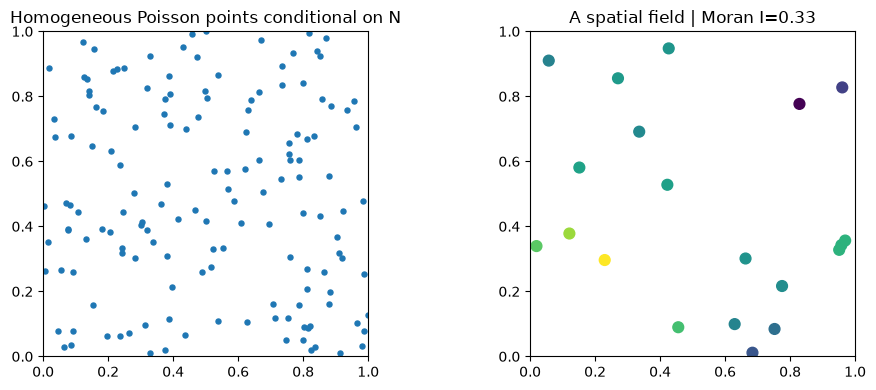

Illustrative Moran I depends on chosen neighborhood distance and null.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
rng=np.random.default_rng(77)
pts=rng.uniform(size=(150,2))
fig,axs=plt.subplots(1,2,figsize=(10,4))
axs[0].scatter(*pts.T,s=13);axs[0].set(xlim=(0,1),ylim=(0,1),title='Homogeneous Poisson points conditional on N')
xy=rng.uniform(size=(20,2))
Z=np.sin(2*np.pi*xy[:,0])+np.sin(2*np.pi*xy[:,1])
D=cdist(xy,xy);W=((D>0)&(D<.3)).astype(float);S=W.sum()
center=Z-Z.mean();I=len(Z)/S*(center@W@center)/(center@center)
axs[1].scatter(*xy.T,c=Z,s=60);axs[1].set(xlim=(0,1),ylim=(0,1),title=f'A spatial field | Moran I={I:.2f}')
for a in axs:a.set_aspect('equal')
plt.tight_layout();plt.show()
print('Illustrative Moran I depends on chosen neighborhood distance and null.')

```mermaid
flowchart LR
    A[Simulate spatial point pattern] --> B[Place sample anchors]
    B --> C[Build disk supports]
    C --> D[Count events per disk]
    D --> E[Compare overlap dependence]
    E --> F[Select justified spatial null]
```

This chapter follows the same structure as the supplied MCLP tutorial: conceptual workflow, formal definition, assumptions, a hand-worked example, executable Python experiments, sensitivity checks, common pitfalls, and a quiz.

---

## Formal Definition and Core Equations

### Notation

| Symbol | Meaning |
|---|---|
| $N(A)$ | point count in spatial set $A$ |
| $\lambda$ | homogeneous Poisson intensity |
| $Y_A=\mathbf{1}\{N(A)>0\}$ | occupied-disk indicator |
| $|A\cap B|$ | intersection area of supports |

$$N(A)\sim\mathrm{Poisson}(\lambda |A|),\qquad P(Y_A=1)=1-e^{-\lambda |A|}.$$

$$\operatorname{Cov}(Y_A,Y_B)=e^{-\lambda(|A|+|B|)}\left[e^{\lambda|A\cap B|}-1\right].$$

For disjoint sets under a homogeneous Poisson process, event counts are independent. For overlapping sets, common events induce positive dependence even under CSR.

---

## Core Mechanisms and Concepts

### Spatial CSR does not mean independent disk occupancies

A Poisson pattern is generated in continuous geography. When the same event lies inside two sampling disks, those two transaction outcomes are logically linked.

### Three distinct null constructions

1. **CSR:** simulate events over the spatial domain, then aggregate to supports.
2. **Point-mark random labeling:** hold pooled event locations fixed while permuting their marks (when appropriate).
3. **Transaction-row shuffling:** hold disk-level covariates fixed and reallocate occupancy indicators; this imposes a separate label exchangeability hypothesis.

### Geography of support

Radius affects area and overlap, and hence occupancy prevalence and dependence. A sample of many disks does not automatically provide that many independent observations.

## Assumptions, Strengths, Limitations, and Trade-offs

Assume homogeneous Poisson intensity and correctly specified disk geometry for the analytic covariance. Strength: exact overlap-based covariance. Limitation: wildfire has seasonal variation and spatially varying intensities, and event processes may be clustered beyond Poisson.

**Trade-off:** larger disks may collect more events but increase overlap and reduce the effective amount of independent information.

## Worked Toy Example

Take two equal disks with radius $r$. They are disjoint when center separation $d\ge2r$. If they intersect, the intersection area is positive and so is covariance of occupancy. This dependence appears even if events follow perfect homogeneous CSR and the antecedent does not affect intensity.

## Python Lab: Set Up the Dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import hypergeom, binom

SEED = 41020001
rng = np.random.default_rng(SEED)
print("Reproducible random seed:", SEED)

Reproducible random seed: 41020001


## Simulate points and disks

Inspect event points and supporting disks in a 100×100 square.

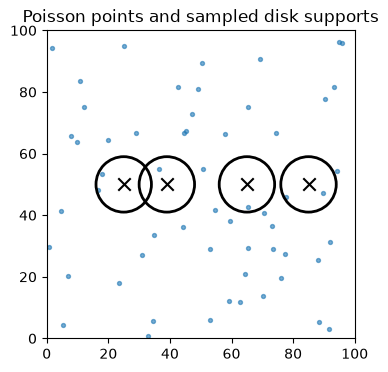

In [3]:
from matplotlib.patches import Circle
L=100;r=9;lam=.006
anchors=np.array([[25,50],[39,50],[65,50],[85,50]])
npnts=rng.poisson(lam*L*L);points=rng.uniform(0,L,size=(npnts,2))
fig,ax=plt.subplots(figsize=(8,4));ax.scatter(points[:,0],points[:,1],s=8,alpha=.6)
for a in anchors:ax.add_patch(Circle(a,r,fill=False,linewidth=2))
ax.scatter(anchors[:,0],anchors[:,1],marker='x',s=80,color='black');ax.set(xlim=(0,L),ylim=(0,L),aspect='equal',title='Poisson points and sampled disk supports');plt.show()

**Interpretation.** The first two supports overlap; points inside their shared area contribute to both outcomes.

## Derive and plot overlap covariance

Use the exact equal-disk intersection formula.

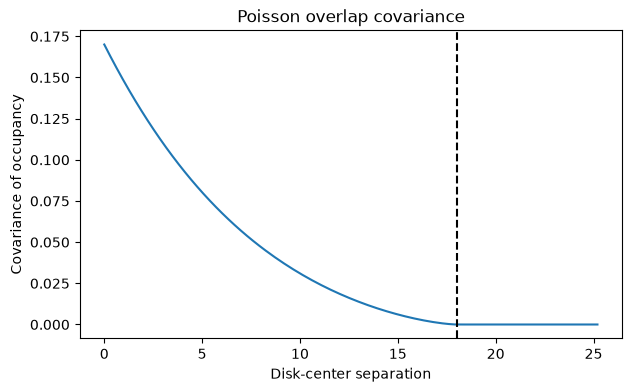

In [4]:
def intersection_area(r,d):
 d=np.asarray(d,float);a=np.zeros_like(d);z=d<2*r
 a[z]=2*r*r*np.arccos(d[z]/(2*r))-.5*d[z]*np.sqrt(np.maximum(0,4*r*r-d[z]**2))
 return a
def occupancy_cov(r,d,lam):
 area=np.pi*r*r;v=intersection_area(r,d)
 return np.exp(-2*lam*area)*np.expm1(lam*v)
d=np.linspace(0,2.8*r,160)
fig,ax=plt.subplots(figsize=(7,4));ax.plot(d,occupancy_cov(r,d,lam));ax.axvline(2*r,linestyle='--',color='black');ax.set(xlabel='Disk-center separation',ylabel='Covariance of occupancy',title='Poisson overlap covariance');plt.show()

**Interpretation.** For separated disks the covariance goes to zero; overlapping occupancy indicators remain correlated even with CSR.

## Estimate covariance from repeated Poisson realizations

Repeatedly generate event points and compute two disk outcomes.

In [5]:
reps=6000;pair=anchors[:2];draws=np.empty((reps,2))
for b in range(reps):
 p=rng.uniform(0,L,size=(rng.poisson(lam*L*L),2))
 draws[b]=[((p-a)**2).sum(axis=1).min(initial=np.inf)<=r*r for a in pair]
emp=np.cov(draws,rowvar=False,ddof=0)[0,1]
analytic=occupancy_cov(r,np.linalg.norm(pair[0]-pair[1]),lam).item()
print({'empirical_covariance':emp,'analytic_covariance':analytic})

{'empirical_covariance': np.float64(0.009701333333333343), 'analytic_covariance': 0.009615884832970982}


**Interpretation.** A shared-event covariance is a property of the data-generating mechanism, not of an association between X and Y.

## Compare expected occupancy under different intensities

Uneven baseline intensity creates different Bernoulli margins even without shared events.

In [6]:
area=np.pi*r*r
print(pd.DataFrame({'intensity':[.001,.003,.006,.01], 'P_disk_occupied':[1-np.exp(-l*area) for l in [.001,.003,.006,.01]]}).round(3))

   intensity  P_disk_occupied
0      0.001            0.225
1      0.003            0.534
2      0.006            0.783
3      0.010            0.922


**Interpretation.** Unequal margins violate uniform allocation of a fixed total unless the null design accounts for them.

---

## Common Pitfalls and Misunderstandings

- CSR is a statement about spatial event generation, not automatic exchangeability of disk-level binary outcomes.
- Nonoverlapping disks can still be nonexchangeable under spatial heterogeneity.
- Point-level label permutation and row-level outcome permutation test different nulls.
- A raster neighborhood summary uses geometric support; this differs from rule support (transaction frequency).
- Increasing Monte Carlo iterations does not remove overlap-induced dependence.

---

## Quiz — Self-Assessment (Answers Hidden)

Try each question before expanding **Answer**. The folded format follows the supplied `mclp.ipynb` template.

### Q1: Under homogeneous CSR, are occupancy indicators for overlapping regions necessarily independent?

A. Yes  
B. No  
C. Only when intensity is large  
D. Only with polygons

<details>
<summary>Answer</summary>

**B. Shared point occurrences induce positive occupancy covariance.**

</details>

---

### Q2: What distinguishes a spatially varying intensity from point interaction?

A. They are always identical  
B. A high-density region can generate apparent clustering without interaction  
C. Interaction is impossible  
D. Only time separates them

<details>
<summary>Answer</summary>

**B. First-order intensity variation can imitate clustering under a homogeneous null.**

</details>

---

### Q3: What is the principal role of Moran’s I?

A. Detect temporal lag  
B. Summarize spatial autocorrelation relative to a weights matrix  
C. Estimate p-values without a null  
D. Prove causation

<details>
<summary>Answer</summary>

**B. Its value and inference depend on W and the chosen reference.**

</details>

---

### Q4: Why does changing a polygon or cylinder radius matter?

A. It only changes computation time  
B. It changes sample supports, dependence and prevalence  
C. It guarantees better accuracy  
D. It removes seasonality

<details>
<summary>Answer</summary>

**B. Scale and overlap alter the data-generating representation and the resulting statistics.**

</details>

---

### Reflection Question (no prescribed solution)

Name one assumption violation in your own research area and propose a simulation to measure how much it matters.


---

## Suggested Reading and STARM Crosswalk

- Agrawal & Srikant (1994): frequent-itemset search (background).
- Hope (1968); Phipson & Smyth (2010): randomization/Monte Carlo p-values (Chapter B).
- Benjamini & Hochberg (1995); Benjamini & Yekutieli (2001): multiple testing and dependence (Chapter C).
- Baddeley, Rubak & Turner (2015): spatial point patterns (Chapter D).
- Winkler et al. (2014): exchangeability blocks and permutation designs (Chapters B, D, E).
- STARM manuscript: Sections 3.3–3.6 for reference assumptions; Section 4 for simulations; Sections 5–6 for empirical limitations.

**Practice task:** Write a short reviewer note distinguishing a descriptive association from an inferential discovery, explicitly naming the null model and its assumptions.